# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan dalam proyek ini adalah **Iris Dataset**, salah satu dataset klasik dalam machine learning yang diperkenalkan oleh ahli statistik Ronald Fisher pada tahun 1936.

**Informasi Dataset:**
- **Nama Dataset**: Iris Dataset
- **Sumber**: `sklearn.datasets.load_iris()` (UCI Machine Learning Repository)
- **Jumlah sampel**: 150 sampel
- **Jumlah fitur**: 4 fitur numerik
- **Target**: 3 kelas spesies bunga (Setosa, Versicolor, Virginica)

**Fitur-fitur yang tersedia:**
1. `sepal length (cm)` — Panjang kelopak bunga
2. `sepal width (cm)` — Lebar kelopak bunga
3. `petal length (cm)` — Panjang mahkota bunga
4. `petal width (cm)` — Lebar mahkota bunga
5. `species` — Label target (0=setosa, 1=versicolor, 2=virginica)

**Tujuan**: Mengklasifikasikan spesies bunga Iris berdasarkan ukuran kelopak (sepal) dan mahkota (petal) bunganya.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library dataset dan preprocessing dari scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib

print('Seluruh library berhasil diimport!')
print(f'Pandas  version : {pd.__version__}')
print(f'NumPy   version : {np.__version__}')

Seluruh library berhasil diimport!
Pandas  version : 2.2.3
NumPy   version : 2.2.1


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset Iris dari sklearn
iris = load_iris()

# Konversi ke DataFrame pandas
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Cek beberapa baris awal untuk memahami struktur data
print('=== 5 BARIS PERTAMA DATASET ===')
print(df.head())
print()
print('=== 5 BARIS TERAKHIR DATASET ===')
print(df.tail())
print()
print(f'Shape dataset: {df.shape[0]} baris x {df.shape[1]} kolom')

# Simpan dataset raw ke folder iris_raw
os.makedirs('../iris_raw', exist_ok=True)
df.to_csv('../iris_raw/iris.csv', index=False)
print('\nDataset raw berhasil disimpan ke ../iris_raw/iris.csv')

=== 5 BARIS PERTAMA DATASET ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

=== 5 BARIS TERAKHIR DATASET ===
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2 

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# ============================================================
# EDA 1: Informasi umum dataset
# ============================================================
print('=== INFO DATASET ===')
df.info()
print()

print('=== STATISTIK DESKRIPTIF ===')
print(df.describe())
print()

# ============================================================
# EDA 2: Cek Missing Values
# ============================================================
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing)
print(f'Total missing values: {missing.sum()}')
print()

# ============================================================
# EDA 3: Cek Duplikat
# ============================================================
print('=== DUPLIKAT DATA ===')
dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup}')
print()

# ============================================================
# EDA 4: Distribusi kelas target
# ============================================================
print('=== DISTRIBUSI KELAS TARGET ===')
print(df['species_name'].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

=== STATISTIK DESKRIPTIF ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%      

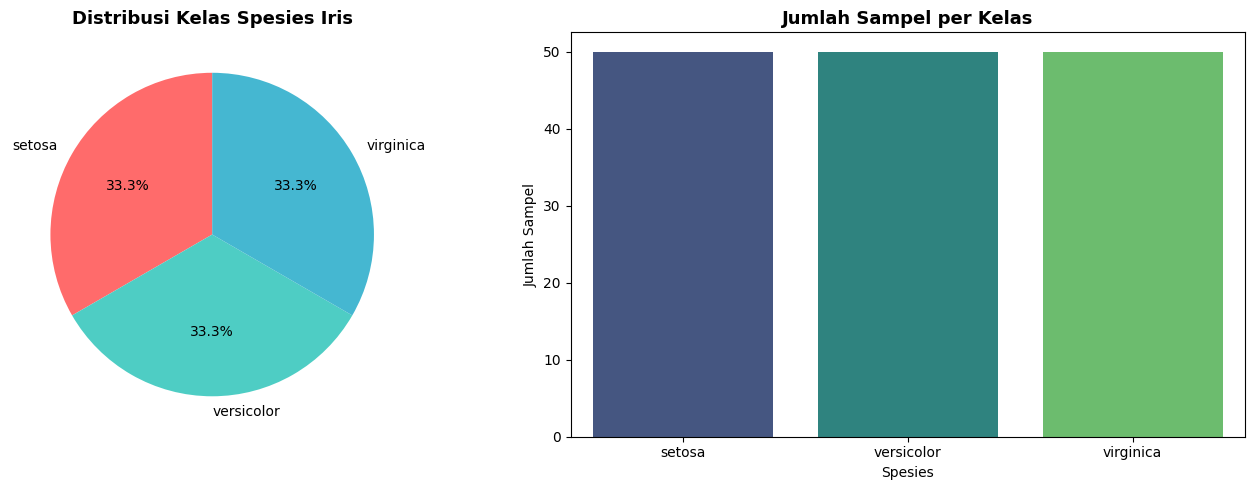

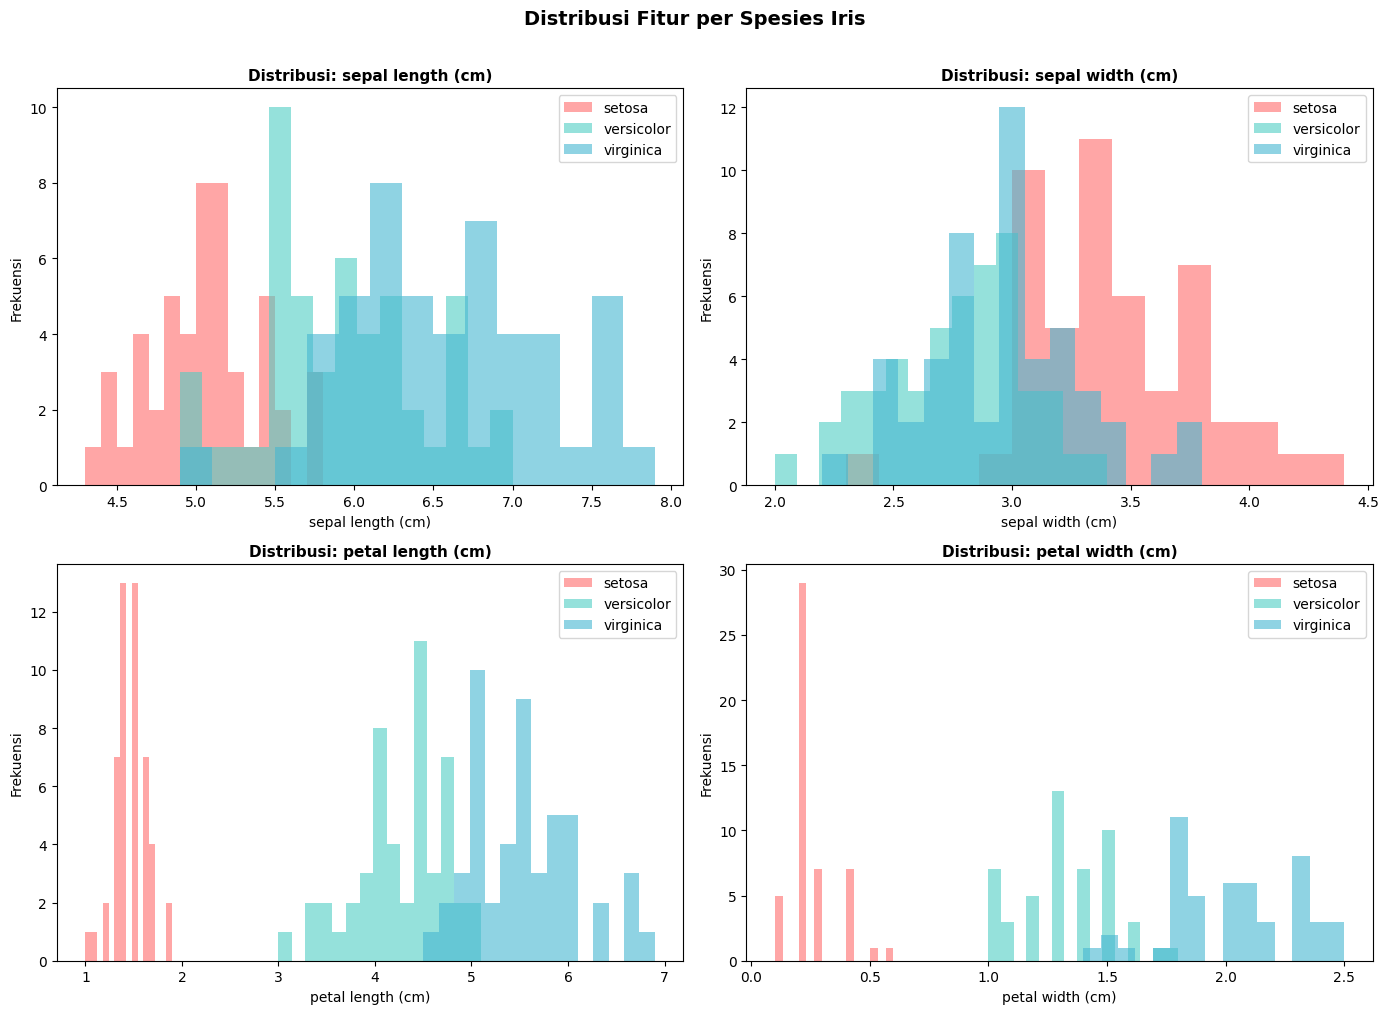

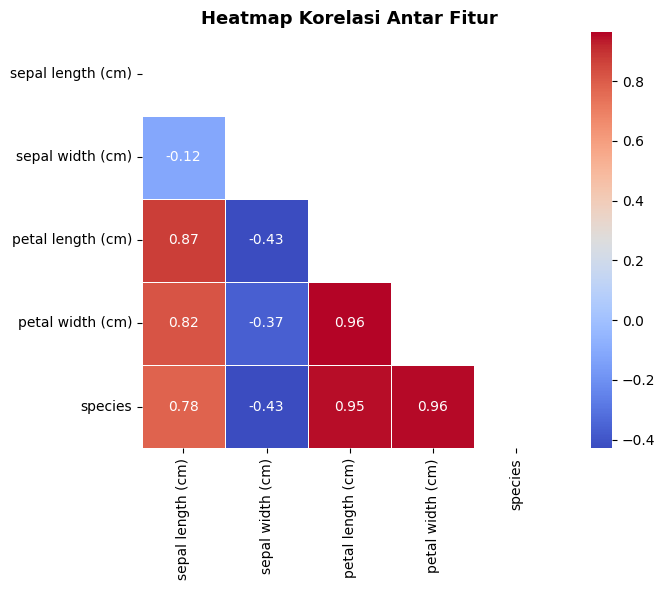

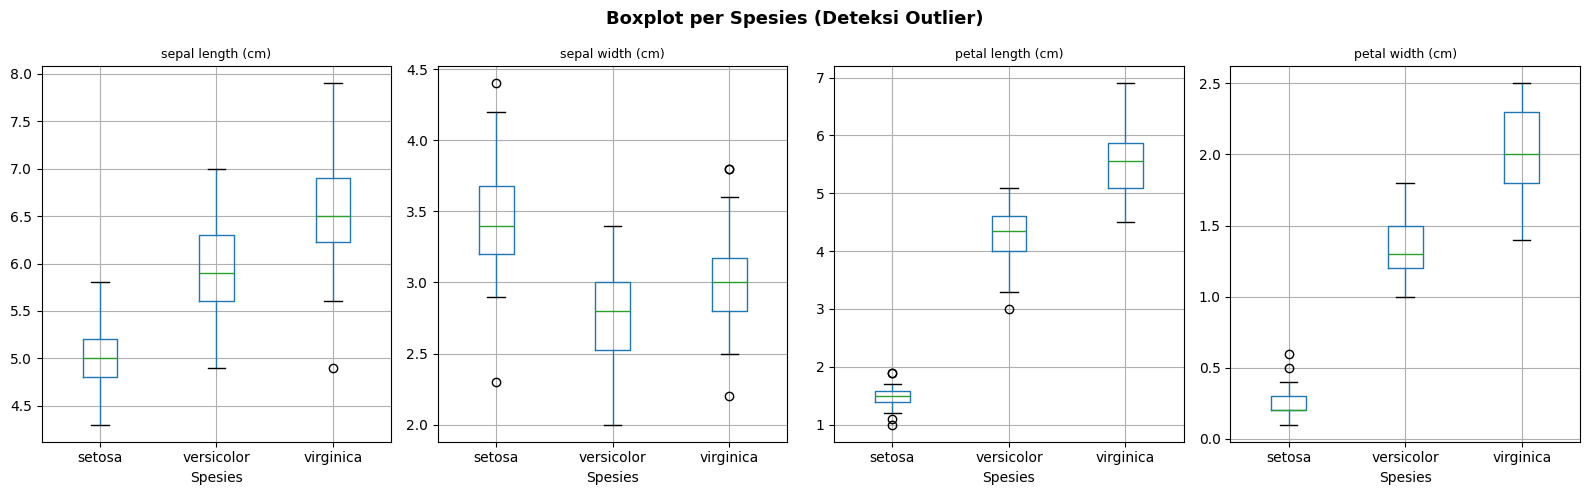

EDA selesai. Semua plot berhasil disimpan.


In [4]:
# ============================================================
# EDA 5: Visualisasi distribusi kelas
# ============================================================
feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart distribusi kelas
counts = df['species_name'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], startangle=90)
axes[0].set_title('Distribusi Kelas Spesies Iris', fontsize=13, fontweight='bold')

# Bar chart jumlah sampel per kelas
sns.countplot(data=df, x='species_name', palette='viridis', ax=axes[1])
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Spesies')
axes[1].set_ylabel('Jumlah Sampel')

plt.tight_layout()
plt.savefig('eda_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# EDA 6: Distribusi setiap fitur per kelas (histogram)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
species_list = df['species_name'].unique()

for i, feature in enumerate(feature_cols):
    for j, species in enumerate(species_list):
        data = df[df['species_name'] == species][feature]
        axes[i].hist(data, alpha=0.6, label=species, bins=15, color=colors[j])
    axes[i].set_title(f'Distribusi: {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.suptitle('Distribusi Fitur per Spesies Iris', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# EDA 7: Heatmap Korelasi
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[feature_cols + ['species']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, square=True, linewidths=0.5)
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# EDA 8: Boxplot (deteksi outlier visual)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, feature in enumerate(feature_cols):
    df.boxplot(column=feature, by='species_name', ax=axes[i])
    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel('Spesies')

plt.suptitle('Boxplot per Spesies (Deteksi Outlier)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA selesai. Semua plot berhasil disimpan.')

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# ============================================================
# PREPROCESSING 1: Menangani Missing Values
# ============================================================
df_clean = df.copy()

print('=== SEBELUM PREPROCESSING ===')
print(f'Shape  : {df_clean.shape}')
print(f'Missing: {df_clean[feature_cols].isnull().sum().sum()} nilai')

# Isi missing value dengan median (jika ada)
for col in feature_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  [{col}] diisi dengan median = {median_val:.4f}')

print(f'Missing setelah penanganan: {df_clean[feature_cols].isnull().sum().sum()} nilai')

# ============================================================
# PREPROCESSING 2: Menghapus Data Duplikat
# ============================================================
print(f'\nDuplikat sebelum: {df_clean.duplicated().sum()} baris')
df_clean = df_clean.drop_duplicates()
print(f'Duplikat setelah : {df_clean.duplicated().sum()} baris')
print(f'Shape setelah hapus duplikat: {df_clean.shape}')

# ============================================================
# PREPROCESSING 3: Deteksi dan Penanganan Outlier (Metode IQR)
# ============================================================
print('\n=== DETEKSI OUTLIER (IQR) ===')
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    # Clipping outlier
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f'  [{col}]: {n_outlier} outlier di-clip ke [{lower:.4f}, {upper:.4f}]')

# ============================================================
# PREPROCESSING 4: Memisahkan Fitur dan Target
# ============================================================
X = df_clean[feature_cols].copy()
y = df_clean['species'].copy()
print(f'\nX (fitur) shape : {X.shape}')
print(f'y (target) shape: {y.shape}')
print(f'Kelas unik      : {sorted(y.unique())} -> {["setosa", "versicolor", "virginica"]}')

# ============================================================
# PREPROCESSING 5: Train-Test Split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nX_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

# ============================================================
# PREPROCESSING 6: Standarisasi Fitur (StandardScaler)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print('\nStatistik X_train setelah StandardScaler:')
print(X_train_scaled_df.describe().round(4))

# ============================================================
# PREPROCESSING 7: Simpan Dataset Preprocessed
# ============================================================
os.makedirs('iris_preprocessing', exist_ok=True)

# Gabungkan fitur dengan label
train_df = X_train_scaled_df.copy()
train_df['species'] = y_train.values
train_df.to_csv('iris_preprocessing/iris_train.csv', index=False)

test_df = X_test_scaled_df.copy()
test_df['species'] = y_test.values
test_df.to_csv('iris_preprocessing/iris_test.csv', index=False)

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df.to_csv('iris_preprocessing/iris_preprocessed.csv', index=False)

# Simpan scaler
joblib.dump(scaler, 'iris_preprocessing/scaler.pkl')

print('\n=== FILE BERHASIL DISIMPAN ===')
print(f'  iris_preprocessing/iris_train.csv       -> {train_df.shape}')
print(f'  iris_preprocessing/iris_test.csv        -> {test_df.shape}')
print(f'  iris_preprocessing/iris_preprocessed.csv-> {full_df.shape}')
print(f'  iris_preprocessing/scaler.pkl')
print('\nPreprocessing selesai!')

=== SEBELUM PREPROCESSING ===
Shape  : (150, 6)
Missing: 0 nilai
Missing setelah penanganan: 0 nilai

Duplikat sebelum: 1 baris
Duplikat setelah : 0 baris
Shape setelah hapus duplikat: (149, 6)

=== DETEKSI OUTLIER (IQR) ===
  [sepal length (cm)]: 0 outlier di-clip ke [3.1500, 8.3500]
  [sepal width (cm)]: 4 outlier di-clip ke [2.0500, 4.0500]
  [petal length (cm)]: 0 outlier di-clip ke [-3.6500, 10.3500]
  [petal width (cm)]: 0 outlier di-clip ke [-1.9500, 4.0500]

X (fitur) shape : (149, 4)
y (target) shape: (149,)
Kelas unik      : [np.int64(0), np.int64(1), np.int64(2)] -> ['setosa', 'versicolor', 'virginica']

X_train: (119, 4) | y_train: (119,)
X_test : (30, 4)  | y_test : (30,)

Statistik X_train setelah StandardScaler:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count           119.0000          119.0000           119.0000   
mean             -0.0000            0.0000             0.0000   
std               1.0042            1.0042             1.0042   
min